# Kernel Token Contradiction - TIKZ export only

Notebook to export TIKZ files for the paper - do not display the full figures. Please refer to `benchmark.ipynb` for a notebook displaying the figures.

In [1]:
import os

os.chdir(os.path.dirname(os.path.abspath("")))

In [2]:
import sys
import typing as t

from src.annotation import *
from src.signals import *
from src.evaluation import *
from src.utils import paths

import matplot2tikz
import numpy as np
from matplotlib import pyplot as plt
from loguru import logger
from sklearn.metrics import precision_recall_curve, auc, roc_curve
%matplotlib inline

logger.remove()
logger.add(
    sys.stderr,
    level="WARNING",
);

In [3]:
TIKZ_OUTPUTS_PATH = paths.output / "evaluations" / "tikz_outputs"
TIKZ_OUTPUTS_PATH.mkdir(exist_ok=True, parents=True)

In [4]:
all_uq_signals: t.List[UQSignal] = [
    SignalTokenLikelihood(),
    SignalMaxLikelihood(),
] + [
    SignalTokenEntropy(delta=delta)
    for delta in [24]
] + [
    SignalCCP(delta=delta, sigma=sigma, size=size)
    for delta in [10, 24]
    for sigma in [3, 5, 8]
    for size in ["L", "M", "S"]
] + [
    SignalSAR(sigma=sigma, size=size)
    for sigma in [3, 5, 8]
    for size in ["L", "M", "S"]
] + [
    SignalKTC(ktc_config_id=ktc_config_id)
    for ktc_config_id in [
        KTCConfig(nu=nu, tau=tau).id
        for nu in [3, 4, 5, 6, 8]
        for tau in [0.1,0.2,0.3,0.4,0.5,0.7]
    ]   
]

In [5]:
MAX_PLOT_PER_CATEGORY = 1
PLOT_STEP=25
MANUAL = 1
INCLUDE_MUCH = True
INCLUDE_MUSHROOM = True

In [6]:
METHOD_NAME = {"scale": "s", "mixture": "m"}

def standardize_name(name:str) -> str:
    if name[:4] == "ktc_":
        ktc_config = KTCConfig.autoconfig(name[4:])
        return f"KTC$_{{\\nu={ktc_config.nu},tau={ktc_config.tau}}}$"        
        
    name = name.replace("ccp", "CCP")
    name = name.replace("sar", "SAR")
    name = name.replace("token_entropy", "Token Entropy")
    name = name.replace("token_likelihood", "Token Likelihood")
    name = name.replace("max_likelihood", "Max Likelihood")
    name = name.replace("_", "-")

    return name

In [7]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
def get_label_and_colors(name):
    if name.startswith("ktc_"):
        return ("KTC", COLORS[0])
    if name.startswith("ccp_"):
        return ("CCP", COLORS[1])
    if name.startswith("sar_"):
        return ("SAR", COLORS[2])
    if name.startswith("token_likelihood"):
        return ("Token Likelihood", COLORS[3])
    if name.startswith("token_entropy"):
        return ("Token Entropy", COLORS[4])
    if name.startswith("max_likelihood"):
        return ("Max Likelihood", COLORS[5])

# Per aggregator | All lang included

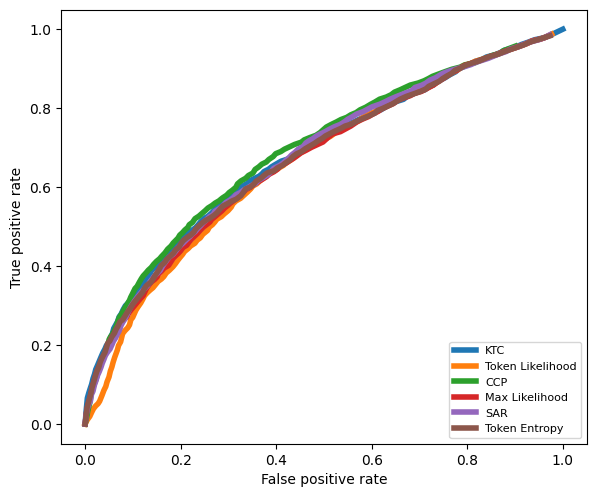

In [8]:
aggregators = ["mean", "max", "geometric", "product"]
N_ROWS = 2
N_COLS = 2
BEST_KTC_CONFIGS_PRODUCT_ROC = []

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 5*N_ROWS)) 
axes = axes.flatten()  # Flatten to easily index

for idx_aggr, aggr in enumerate(aggregators):
    ax = axes[idx_aggr]
    all_fpr_tpr_auc = {}

    for uq_signal in all_uq_signals:
        try:
            fpr, tpr, roc_auc, _, _, _, _ = (
                get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM).get_rocauc_prauc(aggregator=aggr)
            )
        except NoChunkEval:
            continue
        all_fpr_tpr_auc[uq_signal.signal_name] = (fpr, tpr, roc_auc)

    sorted_names = sorted(
        all_fpr_tpr_auc, key=lambda k: all_fpr_tpr_auc[k][2], reverse=True
    )

    count_ktc = 0
    count_ccp = 0
    count_sar = 0
    TO_PLOT = {}
    for name in sorted_names:
        if "ktc_" in name:
            count_ktc += 1
            if count_ktc <= 7 and idx_aggr == 3:
                BEST_KTC_CONFIGS_PRODUCT_ROC.append(name[4:])
            if count_ktc > MAX_PLOT_PER_CATEGORY:
                continue
        if "ccp_" in name:
            count_ccp += 1
            if count_ccp > MAX_PLOT_PER_CATEGORY:
                continue
        if "sar_" in name:
            count_sar += 1
            if count_sar > MAX_PLOT_PER_CATEGORY:
                continue
        
        fpr, tpr, roc_auc = all_fpr_tpr_auc[name]
        label, color = get_label_and_colors(name)
        TO_PLOT[label] = (fpr, tpr, color)

    for label in "KTC", "Token Likelihood", "CCP", "Max Likelihood", "SAR", "Token Entropy", :
        fpr, tpr, color = TO_PLOT[label]
        ax.plot(fpr[::PLOT_STEP], tpr[::PLOT_STEP], label=label, linewidth=4)

    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()

axes = axes.reshape(N_ROWS, N_COLS)  # Reshape back to 2D for easier indexing
for idx_x in range(2):
    for idx_y in range(2):
        for y in range(2):
            if y != idx_y:
                for x in range(2):
                    axes[y, x].set_visible(False)
            else:
                for x in range(2):
                    if x == idx_x:
                        axes[y, idx_x].set_visible(True)
                    else:
                        axes[y, x].set_visible(False)
        matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"roc_per_agg_{idx_x}_{idx_y}.tikz",     extra_axis_parameters=[
            'every mark/.append style={solid}, very thick',
                    'every axis plot/.append style={very thick, line width=1.5pt}',
                    'legend style={font=\\normalsize}',
                    'legend columns=2',
                    'legend image post style={scale=0.4}',
                    'x label style={font=\\large}',
			        'y label style={font=\\large}',
        ],
    )

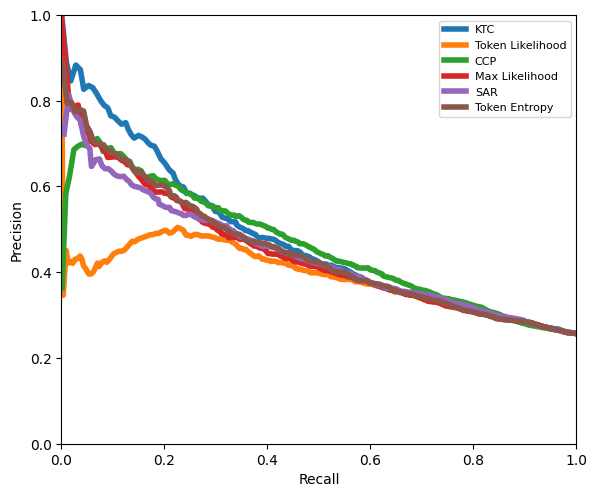

In [9]:
aggregators = ["mean", "max", "geometric", "product"]
N_ROWS = 2
N_COLS = 2
BEST_KTC_CONFIGS_PRODUCT_PR = []
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 5*N_ROWS)) 
axes = axes.flatten()  # Flatten to easily index

for idx_aggr, aggr in enumerate(aggregators):
    ax = axes[idx_aggr]
    all_prec_rec_auc = {}

    for uq_signal in all_uq_signals:
        try:
            _, _, _, prc, rec, pr_auc, _ = (
                get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM).get_rocauc_prauc(aggregator=aggr)
            )
        except NoChunkEval:
            continue
        all_prec_rec_auc[uq_signal.signal_name] = (prc, rec, pr_auc)

    sorted_names = sorted(
        all_prec_rec_auc, key=lambda k: all_prec_rec_auc[k][2], reverse=True
    )

    count_ktc = 0
    count_ccp = 0
    count_sar = 0
    TO_PLOT = {}
    for name in sorted_names:
        if "ktc_" in name:
            count_ktc += 1
            if count_ktc <= 7 and idx_aggr == 3:
                BEST_KTC_CONFIGS_PRODUCT_PR.append(name[4:])
            if count_ktc > MAX_PLOT_PER_CATEGORY:
                continue
        if "ccp_" in name:
            count_ccp += 1
            if count_ccp > MAX_PLOT_PER_CATEGORY:
                continue
        if "sar_" in name:
            count_sar += 1
            if count_sar > MAX_PLOT_PER_CATEGORY:
                continue

        prc, rec, pr_auc = all_prec_rec_auc[name]
        label, color = get_label_and_colors(name)
        TO_PLOT[label] = (prc, rec, color)

    for label in "KTC", "Token Likelihood", "CCP", "Max Likelihood", "SAR", "Token Entropy", :
        prc, rec, color = TO_PLOT[label]
        ax.plot(rec[::PLOT_STEP], prc[::PLOT_STEP], label=label, linewidth=4)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.legend(fontsize=8, loc="upper right")

fig.tight_layout()

axes = axes.reshape(N_ROWS, N_COLS)  # Reshape back to 2D for easier indexing
for idx_x in range(2):
    for idx_y in range(2):
        for y in range(2):
            if y != idx_y:
                for x in range(2):
                    axes[y, x].set_visible(False)
            else:
                for x in range(2):
                    if x == idx_x:
                        axes[y, idx_x].set_visible(True)
                    else:
                        axes[y, x].set_visible(False)
        matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"pr_per_agg_{idx_x}_{idx_y}.tikz",     extra_axis_parameters=[
            'every mark/.append style={solid}, very thick',
                    'every axis plot/.append style={very thick, line width=1.5pt}',
                    'legend style={font=\\normalsize}',
                    'legend columns=2',
                    'legend image post style={scale=0.4}',
                    'x label style={font=\\large}',
			        'y label style={font=\\large}',
        ],
    )

# Per lang | Aggregator=product

In [10]:
PLOT_STEP = 6

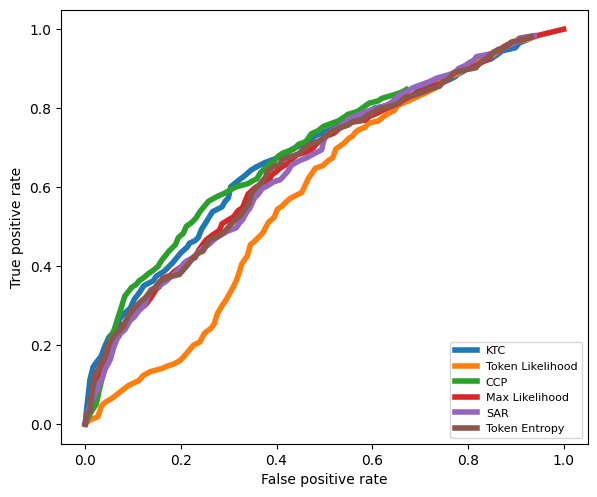

In [11]:
langs = ["en", "fr", "es", "de"]
aggregators = ["product"]
N_ROWS = 2
N_COLS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 5*N_ROWS))
axes = axes.flatten()

for idx_lang, lang in enumerate(langs):
    ax = axes[idx_lang]
    all_fpr_tpr_auc = {}

    for uq_signal in all_uq_signals:
        best = (None, None, -1)
        for agg in aggregators:
            try:
                fpr, tpr, roc_auc, _, _, _, _ = (
                    get_evaluation(uq_signal, lang=lang, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM).get_rocauc_prauc(aggregator=agg)
                )
            except NoChunkEval:
                continue
            if roc_auc > best[-1]:
                best = fpr, tpr, roc_auc
    
        all_fpr_tpr_auc[uq_signal.signal_name] = best

    sorted_names = sorted(
        all_fpr_tpr_auc, key=lambda k: all_fpr_tpr_auc[k][2], reverse=True
    )

    count_ktc = 0
    count_ccp = 0
    count_sat = 0
    TO_PLOT = {}
    for name in sorted_names:
        if "ktc_" in name:
            count_ktc += 1
            if count_ktc > MAX_PLOT_PER_CATEGORY:
                continue
        if "ccp_" in name:
            count_ccp += 1
            if count_ccp > MAX_PLOT_PER_CATEGORY:
                continue
        if "sar_" in name:
            count_sat += 1
            if count_sat > MAX_PLOT_PER_CATEGORY:
                continue

        fpr, tpr, roc_auc = all_fpr_tpr_auc[name]
        label, color = get_label_and_colors(name)
        TO_PLOT[label] = (fpr, tpr, color)

    for label in "KTC", "Token Likelihood", "CCP", "Max Likelihood", "SAR", "Token Entropy", :
        fpr, tpr, color = TO_PLOT[label]
        ax.plot(fpr[::PLOT_STEP], tpr[::PLOT_STEP], label=label, linewidth=4)

    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()

axes = axes.reshape(N_ROWS, N_COLS)  # Reshape back to 2D for easier indexing
for idx_x in range(2):
    for idx_y in range(2):
        for y in range(2):
            if y != idx_y:
                for x in range(2):
                    axes[y, x].set_visible(False)
            else:
                for x in range(2):
                    if x == idx_x:
                        axes[y, idx_x].set_visible(True)
                    else:
                        axes[y, x].set_visible(False)
        matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"roc_per_lang_{idx_x}_{idx_y}.tikz",     extra_axis_parameters=[
            'every mark/.append style={solid}, very thick',
                    'every axis plot/.append style={very thick, line width=1.5pt}',
                    'legend style={font=\\normalsize}',
                    'legend columns=2',
                    'legend image post style={scale=0.4}',
                    'x label style={font=\\large}',
			        'y label style={font=\\large}',
        ],
    )

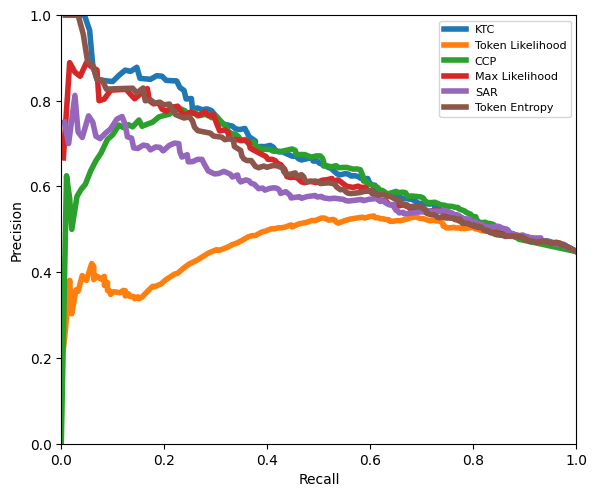

In [12]:
langs = ["en", "fr", "es", "de"]
aggregators = ["product"]
N_ROWS = 2
N_COLS = 2
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6*N_COLS, 5*N_ROWS))
axes = axes.flatten()

for idx_lang, lang in enumerate(langs):
    ax = axes[idx_lang]
    all_prec_rec_auc = {}

    for uq_signal in all_uq_signals:
        best = (None, None, -1)
        for agg in aggregators:
            try:
                _, _, _, prc, rec, pr_auc, _ = (
                    get_evaluation(uq_signal, lang=lang, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM).get_rocauc_prauc(aggregator="max")
                )
            except NoChunkEval:
                continue
            if pr_auc > best[-1]:
                best = prc, rec, pr_auc
        all_prec_rec_auc[uq_signal.signal_name] = best

    sorted_names = sorted(
        all_prec_rec_auc, key=lambda k: all_prec_rec_auc[k][2], reverse=True
    )

    count_ktc = 0
    count_ccp = 0
    count_sar = 0
    TO_PLOT = {}
    for name in sorted_names:
        if "ktc_" in name:
            count_ktc += 1
            if count_ktc > MAX_PLOT_PER_CATEGORY:
                continue
        if "ccp_" in name:
            count_ccp += 1
            if count_ccp > MAX_PLOT_PER_CATEGORY:
                continue
        if "sar_" in name:
            count_sar += 1
            if count_sar > MAX_PLOT_PER_CATEGORY:
                continue

        prc, rec, pr_auc = all_prec_rec_auc[name]
        label, color = get_label_and_colors(name)
        TO_PLOT[label] = (prc, rec, color)
        
    for label in "KTC", "Token Likelihood", "CCP", "Max Likelihood", "SAR", "Token Entropy", :
        prc, rec, color = TO_PLOT[label]
        ax.plot(rec[::PLOT_STEP], prc[::PLOT_STEP], label=label, linewidth=4)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.legend(fontsize=8)

fig.tight_layout()

axes = axes.reshape(N_ROWS, N_COLS)  # Reshape back to 2D for easier indexing
for idx_x in range(2):
    for idx_y in range(2):
        for y in range(2):
            if y != idx_y:
                for x in range(2):
                    axes[y, x].set_visible(False)
            else:
                for x in range(2):
                    if x == idx_x:
                        axes[y, idx_x].set_visible(True)
                    else:
                        axes[y, x].set_visible(False)
        matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"pr_per_lang_{idx_x}_{idx_y}.tikz",     extra_axis_parameters=[
            'every mark/.append style={solid}, very thick',
                    'every axis plot/.append style={very thick, line width=1.5pt}',
                    'legend style={font=\\normalsize}',
                    'legend columns=2',
                    'legend image post style={scale=0.4}',
                    'x label style={font=\\large}',
			        'y label style={font=\\large}',
        ],
    )

# Best signals compared to computation time

You should manually fill the computation times based on what you observed during computation.

In [13]:
ENGLISH_ONLY: bool = False

In [14]:
# Was the following in our computations - these values are taken in the following
# {'DM1qsY2yGVSu3A0vOJN_0w',
#  'RYxmoyp1awYParfCjjxgnQ',
#  'S6YhbBdK56RFwi73kU8fhw',
#  'Wo0GoYjpJhYzHUGLe8dFQQ',
#  'aafoWU2PoOZpccAy7q6o5Q',
#  'b55qBpKqipiD5DA2eoARmw',
#  'eHB-FfM9pX3kFfR9TjPz6g',
#  'lFKnrf2rr26hoamydKC1Aw'}
set(BEST_KTC_CONFIGS_PRODUCT_PR).union(set(BEST_KTC_CONFIGS_PRODUCT_ROC))

{'DM1qsY2yGVSu3A0vOJN_0w',
 'RYxmoyp1awYParfCjjxgnQ',
 'S6YhbBdK56RFwi73kU8fhw',
 'Wo0GoYjpJhYzHUGLe8dFQQ',
 'aafoWU2PoOZpccAy7q6o5Q',
 'b55qBpKqipiD5DA2eoARmw',
 'eHB-FfM9pX3kFfR9TjPz6g',
 'lFKnrf2rr26hoamydKC1Aw'}

In [15]:
all_uq_signals: t.List[UQSignal] = [
    SignalTokenLikelihood(),
    SignalMaxLikelihood(),
] + [
    SignalTokenEntropy(delta=delta)
    for delta in [5, 10, 24]
] + [
    SignalCCP(delta=delta, sigma=sigma, size=size)
    for delta in [10, 24]
    for sigma in [3, 5, 8]
    for size in ["L", "M", "S"]
] + [
    SignalSAR(sigma=sigma, size=size)
    for sigma in [3, 5, 8]
    for size in ["L", "M", "S"]
] + [
    SignalKTC(ktc_config_id=ktc_config_id)
    for ktc_config_id in [
        KTCConfig(nu=nu, tau=tau).id
        for nu in [3, 4, 5, 6, 8]
        for tau in [0.1,0.2,0.3,0.4,0.5,0.7]
    ]   
]

In [16]:
# Agerage duration of the LLM computation for generating the outputs
LLM_COMPUTATION = 127.1
# Duration of the signal computation - some methods have both CPU and GPU times
SIGNAL_TIMES = {
    'token_likelihood': dict(t=3.36, cpu_only=None),
    'max_likelihood': dict(t=3.34, cpu_only=None),
    'token_entropy_5': dict(t=3.54, cpu_only=None),
    'token_entropy_10': dict(t=3.54, cpu_only=None),
    'token_entropy_24': dict(t=3.52, cpu_only=None),
    'ccp_10_3': dict(t=112.0, cpu_only=1460),
    'ccp_10_3_M': dict(t=58.6, cpu_only=469),
    'ccp_10_3_S': dict(t=50.6, cpu_only=240),
    'ccp_10_5': dict(t=130.4, cpu_only=1861),
    'ccp_10_5_M': dict(t=62.6, cpu_only=581),
    'ccp_10_5_S': dict(t=51.3, cpu_only=280),
    'ccp_10_8': dict(t=145.4, cpu_only=2350),
    'ccp_10_8_M': dict(t=69.2, cpu_only=746),
    'ccp_10_8_S': dict(t=51.8, cpu_only=337),
    'ccp_24_3': dict(t=147.3, cpu_only=2622),
    'ccp_24_3_M': dict(t=69.9, cpu_only=835),
    'ccp_24_3_S': dict(t=55.0, cpu_only=477),
    'ccp_24_5': dict(t=171.2, cpu_only=3496),
    'ccp_24_5_M': dict(t=78.6, cpu_only=1093),
    'ccp_24_5_S': dict(t=56.9, cpu_only=615),
    'ccp_24_8': dict(t=206.7, cpu_only=4747),
    'ccp_24_8_M': dict(t=91.6, cpu_only=1480),
    'ccp_24_8_S': dict(t=61.8, cpu_only=913),
    'sar_3': dict(t=14.1, cpu_only=275),
    'sar_3_M': dict(t=8.1, cpu_only=101),
    'sar_3_S': dict(t=7.0, cpu_only=78),
    'sar_5': dict(t=16.7, cpu_only=374),
    'sar_5_M': dict(t=9.0, cpu_only=131),
    'sar_5_S': dict(t=7.3, cpu_only=88),
    'sar_8': dict(t=20.7, cpu_only=521),
    'sar_8_M': dict(t=10.4, cpu_only=171),
    'sar_8_S': dict(t=7.5, cpu_only=104),
    'ktc_DM1qsY2yGVSu3A0vOJN_0w': dict(t=7.2, cpu_only=None),
    'ktc_RYxmoyp1awYParfCjjxgnQ': dict(t=7.2, cpu_only=None),
    'ktc_S6YhbBdK56RFwi73kU8fhw': dict(t=7.2, cpu_only=None),
    'ktc_Wo0GoYjpJhYzHUGLe8dFQQ': dict(t=7.2, cpu_only=None),
    'ktc_aafoWU2PoOZpccAy7q6o5Q': dict(t=7.2, cpu_only=None),
    'ktc_b55qBpKqipiD5DA2eoARmw': dict(t=7.2, cpu_only=None),
    'ktc_eHB-FfM9pX3kFfR9TjPz6g': dict(t=7.2, cpu_only=None),
    'ktc_lFKnrf2rr26hoamydKC1Aw': dict(t=7.2, cpu_only=None),
}

In [17]:
MANUAL = 1
INCLUDE_MUCH = True
INCLUDE_MUSHROOM = True

In [18]:
REC_THD = 0.20
signal_name_to_eval = {}

for uq_signal in all_uq_signals:

    # ================ PR in all lang at high precision ================
    evaluation = get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM)
    in_container = evaluation.product_in
    out_container = evaluation.product_out

    # Predictors and labels
    predictor = np.concatenate([in_container, out_container])
    labels = np.concatenate(
        [
            np.ones(in_container.shape[0], dtype=int),
            np.zeros(out_container.shape[0], dtype=int),
        ]
    )

    # Computing PR and ROC curves
    prc, rec, _ = precision_recall_curve(labels, predictor)
    
    # Finding the index for partial AUC
    pauc_idx = None 
    for idx, val in enumerate(rec):
        if val<=REC_THD:
            pauc_idx = idx
            break

    partial_pr_auc = auc(rec[pauc_idx:], prc[pauc_idx:]) / REC_THD
    
    # ================ ROC-AUC in all lang ================
    evaluation = get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM, lang="en" if ENGLISH_ONLY else None)
    in_container = evaluation.product_in
    out_container = evaluation.product_out

    # Predictors and labels
    predictor = np.concatenate([in_container, out_container])
    labels = np.concatenate(
        [
            np.ones(in_container.shape[0], dtype=int),
            np.zeros(out_container.shape[0], dtype=int),
        ]
    )

    # Computing PR and ROC curves
    fpr, tpr, _ = roc_curve(labels, predictor)
    roc_auc = auc(fpr, tpr)

    # Saving
    signal_name_to_eval[uq_signal.signal_name] = (partial_pr_auc, roc_auc)


KTC (Ours) [ktc_Wo0GoYjpJhYzHUGLe8dFQQ] : t=0.0566 roc_auc=0.6795 precision-focused=0.7483
KTC (Ours) [ktc_lFKnrf2rr26hoamydKC1Aw] : t=0.0566 roc_auc=0.6786 precision-focused=0.7590
KTC (Ours) [ktc_b55qBpKqipiD5DA2eoARmw] : t=0.0566 roc_auc=0.6787 precision-focused=0.7540
KTC (Ours) [ktc_RYxmoyp1awYParfCjjxgnQ] : t=0.0566 roc_auc=0.6779 precision-focused=0.7808
KTC (Ours) [ktc_DM1qsY2yGVSu3A0vOJN_0w] : t=0.0566 roc_auc=0.6725 precision-focused=0.7704
KTC (Ours) [ktc_S6YhbBdK56RFwi73kU8fhw] : t=0.0566 roc_auc=0.6767 precision-focused=0.7515
KTC (Ours) [ktc_aafoWU2PoOZpccAy7q6o5Q] : t=0.0566 roc_auc=0.6742 precision-focused=0.7794
KTC (Ours) [ktc_eHB-FfM9pX3kFfR9TjPz6g] : t=0.0566 roc_auc=0.6751 precision-focused=0.7434
CCP (gpu) [ccp_10_3] : t=0.8812 roc_auc=0.6809 precision-focused=0.5923
CCP (gpu) [ccp_10_3_M] : t=0.4611 roc_auc=0.6670 precision-focused=0.6316
CCP (gpu) [ccp_10_3_S] : t=0.3981 roc_auc=0.5644 precision-focused=0.3449
CCP (gpu) [ccp_10_5] : t=1.0260 roc_auc=0.6885 preci

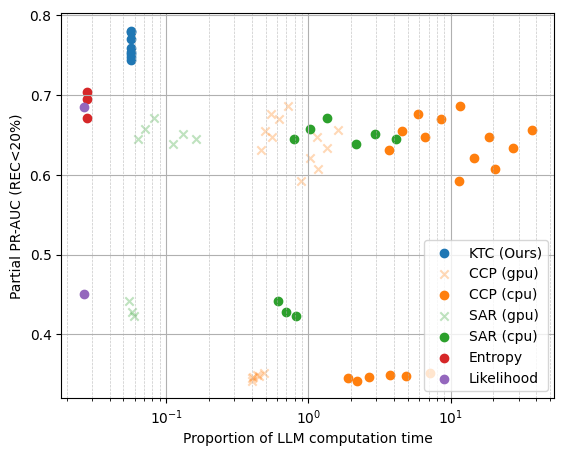

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORS = ["#1f77b4", "#ff7f0e", "#ff7f0e", "#2ca02c", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
groups = [
    ("KTC (Ours)", False, lambda signal_name: ("ktc_" in signal_name) and (signal_name in SIGNAL_TIMES)),
    ("CCP (gpu)", False, lambda signal_name: "ccp_" in signal_name),
    ("CCP (cpu)", True, lambda signal_name: "ccp_" in signal_name),
    ("SAR (gpu)", False, lambda signal_name: "sar_" in signal_name),
    ("SAR (cpu)", True, lambda signal_name: "sar_" in signal_name),
    ("Entropy", False, lambda signal_name: "token_entropy" in signal_name),
    ("Likelihood", False, lambda signal_name: "_likelihood" in signal_name),
]

for idx, (title, get_cpu_only_val, signal_test) in enumerate(groups):
    
    all_times = []
    all_pr_pauc = []
    all_roc_auc = []

    for signal_name, (partial_pr_auc, roc_auc) in signal_name_to_eval.items():
        if not signal_test(signal_name):
            continue

        if get_cpu_only_val:
            all_times.append(SIGNAL_TIMES[signal_name]["cpu_only"] / LLM_COMPUTATION)
        else:
            all_times.append(SIGNAL_TIMES[signal_name]["t"] / LLM_COMPUTATION)

        all_pr_pauc.append(partial_pr_auc)
        all_roc_auc.append(roc_auc)

        
        print(f"{title} [{signal_name}] : t={all_times[-1]:.4f} roc_auc={roc_auc:.4f} precision-focused={partial_pr_auc:.4f}")

    alpha = 0.3 if "(gpu)" in title else 1.0
    marker = "x" if "(gpu)" in title else "o"

    axes[0].scatter(all_times, all_roc_auc, label=title, alpha=alpha, color=COLORS[idx], marker=marker)
    axes[1].scatter(all_times, all_pr_pauc, label=title, alpha=alpha, color=COLORS[idx], marker=marker)
    

axes[0].legend(loc='lower right')
# axes[0].set_title(f"ROC-AUC {'in ENGLISH' if ENGLISH_ONLY else ''}")
axes[0].set_xlabel("Proportion of LLM computation time")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_xscale("log")
axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.8)
axes[0].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

axes[1].legend()
# axes[1].set_title("Partial PR-AUC focusing on High Precision")
axes[1].set_xlabel("Proportion of LLM computation time")
axes[1].set_ylabel("Partial PR-AUC (REC<20%)")
axes[1].set_xscale("log")
axes[1].grid(which='major', linestyle='-', linewidth=0.8)
axes[1].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

for idx in range(2):
    axes[1 - idx].set_visible(False)
    axes[idx].set_visible(True)
    matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"compute_time_{idx}.tikz",     extra_axis_parameters=[
        'every mark/.append style={solid}, very thick'
    ])


# Hyperparameter generalization

We use the same hyperparameters that were selected because they were the best for the manual-only samples, and we evaluate them on MUCH dataset, excluding manually-annotated samples to evaluate generalization.

In [20]:
MANUAL = -1
INCLUDE_MUCH = True
INCLUDE_MUSHROOM = False

In [21]:
REC_THD = 0.20
signal_name_to_eval = {}

for uq_signal in all_uq_signals:

    # ================ PR in all lang at high precision ================
    evaluation = get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM)
    in_container = evaluation.product_in
    out_container = evaluation.product_out

    # Predictors and labels
    predictor = np.concatenate([in_container, out_container])
    labels = np.concatenate(
        [
            np.ones(in_container.shape[0], dtype=int),
            np.zeros(out_container.shape[0], dtype=int),
        ]
    )

    # Computing PR and ROC curves
    prc, rec, _ = precision_recall_curve(labels, predictor)
    
    # Finding the index for partial AUC
    pauc_idx = None 
    for idx, val in enumerate(rec):
        if val<=REC_THD:
            pauc_idx = idx
            break

    partial_pr_auc = auc(rec[pauc_idx:], prc[pauc_idx:]) / REC_THD
    
    # ================ ROC-AUC in ENGLISH ================
    evaluation = get_evaluation(uq_signal, manual=MANUAL, include_much=INCLUDE_MUCH, include_mushroom=INCLUDE_MUSHROOM, lang="en" if ENGLISH_ONLY else None)
    in_container = evaluation.product_in
    out_container = evaluation.product_out

    # Predictors and labels
    predictor = np.concatenate([in_container, out_container])
    labels = np.concatenate(
        [
            np.ones(in_container.shape[0], dtype=int),
            np.zeros(out_container.shape[0], dtype=int),
        ]
    )

    # Computing PR and ROC curves
    fpr, tpr, _ = roc_curve(labels, predictor)
    roc_auc = auc(fpr, tpr)

    # Saving
    signal_name_to_eval[uq_signal.signal_name] = (partial_pr_auc, roc_auc)


KTC (Ours) [ktc_Wo0GoYjpJhYzHUGLe8dFQQ] : t=0.0566 roc_auc=0.7480 precision-focused=0.9354
KTC (Ours) [ktc_lFKnrf2rr26hoamydKC1Aw] : t=0.0566 roc_auc=0.7503 precision-focused=0.9311
KTC (Ours) [ktc_b55qBpKqipiD5DA2eoARmw] : t=0.0566 roc_auc=0.7482 precision-focused=0.9349
KTC (Ours) [ktc_RYxmoyp1awYParfCjjxgnQ] : t=0.0566 roc_auc=0.7524 precision-focused=0.9352
KTC (Ours) [ktc_DM1qsY2yGVSu3A0vOJN_0w] : t=0.0566 roc_auc=0.7481 precision-focused=0.9162
KTC (Ours) [ktc_S6YhbBdK56RFwi73kU8fhw] : t=0.0566 roc_auc=0.7476 precision-focused=0.9311
KTC (Ours) [ktc_aafoWU2PoOZpccAy7q6o5Q] : t=0.0566 roc_auc=0.7520 precision-focused=0.9336
KTC (Ours) [ktc_eHB-FfM9pX3kFfR9TjPz6g] : t=0.0566 roc_auc=0.7466 precision-focused=0.9289
CCP (gpu) [ccp_10_3] : t=0.8812 roc_auc=0.7665 precision-focused=0.8881
CCP (gpu) [ccp_10_3_M] : t=0.4611 roc_auc=0.7641 precision-focused=0.9008
CCP (gpu) [ccp_10_3_S] : t=0.3981 roc_auc=0.5494 precision-focused=0.4725
CCP (gpu) [ccp_10_5] : t=1.0260 roc_auc=0.7725 preci

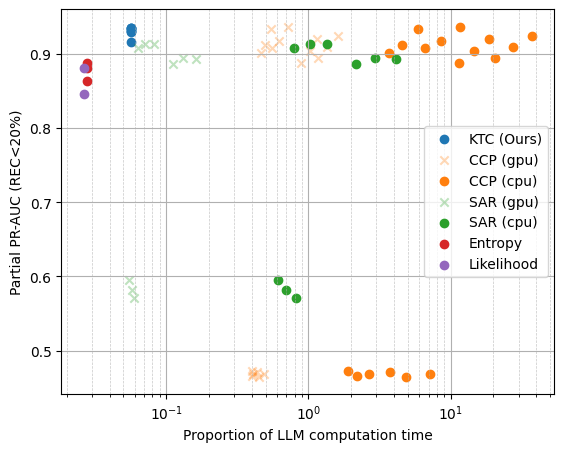

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

COLORS = ["#1f77b4", "#ff7f0e", "#ff7f0e", "#2ca02c", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
groups = [
    ("KTC (Ours)", False, lambda signal_name: ("ktc_" in signal_name) and (signal_name in SIGNAL_TIMES)),
    ("CCP (gpu)", False, lambda signal_name: "ccp_" in signal_name),
    ("CCP (cpu)", True, lambda signal_name: "ccp_" in signal_name),
    ("SAR (gpu)", False, lambda signal_name: "sar_" in signal_name),
    ("SAR (cpu)", True, lambda signal_name: "sar_" in signal_name),
    ("Entropy", False, lambda signal_name: "token_entropy" in signal_name),
    ("Likelihood", False, lambda signal_name: "_likelihood" in signal_name),
]

for idx, (title, get_cpu_only_val, signal_test) in enumerate(groups):
    
    all_times = []
    all_pr_pauc = []
    all_roc_auc = []

    for signal_name, (partial_pr_auc, roc_auc) in signal_name_to_eval.items():
        if not signal_test(signal_name):
            continue

        if get_cpu_only_val:
            all_times.append(SIGNAL_TIMES[signal_name]["cpu_only"] / LLM_COMPUTATION)
        else:
            all_times.append(SIGNAL_TIMES[signal_name]["t"] / LLM_COMPUTATION)

        all_pr_pauc.append(partial_pr_auc)
        all_roc_auc.append(roc_auc)

        print(f"{title} [{signal_name}] : t={all_times[-1]:.4f} roc_auc={roc_auc:.4f} precision-focused={partial_pr_auc:.4f}")

    alpha = 0.3 if "(gpu)" in title else 1.0
    marker = "x" if "(gpu)" in title else "o"

    axes[0].scatter(all_times, all_roc_auc, label=title, alpha=alpha, color=COLORS[idx], marker=marker)
    axes[1].scatter(all_times, all_pr_pauc, label=title, alpha=alpha, color=COLORS[idx], marker=marker)
    

axes[0].legend(loc='lower right')
# axes[0].set_title(f"ROC-AUC {'in ENGLISH' if ENGLISH_ONLY else ''}")
axes[0].set_xlabel("Proportion of LLM computation time")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_xscale("log")
axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.8)
axes[0].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

axes[1].legend()
# axes[1].set_title("Partial PR-AUC focusing on High Precision")
axes[1].set_xlabel("Proportion of LLM computation time")
axes[1].set_ylabel("Partial PR-AUC (REC<20%)")
axes[1].set_xscale("log")
axes[1].grid(which='major', linestyle='-', linewidth=0.8)
axes[1].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

for idx in range(2):
    axes[1 - idx].set_visible(False)
    axes[idx].set_visible(True)
    matplot2tikz.save(TIKZ_OUTPUTS_PATH / f"compute_time_much_test_{idx}.tikz",     extra_axis_parameters=[
        'every mark/.append style={solid}, very thick'
    ])
